# Simulator Low-Pass Post-Processing (`LowPassFilter`) Demo

White-noise excitation of LTI / piecewise-linear systems often leaves high-frequency
glitches on the generated series (**Wiener** is especially affected).
`LowPassFilter` provides optional post-processing:

- **Adaptive cutoff**: estimate a Nyquist-relative cutoff from the cumulative spectral
  energy ratio (`energy_ratio`) of a reference series
- **Manual override**: `cutoff` fully replaces the adaptive estimate
- **Zero-phase filtering**: Butterworth + `sosfiltfilt` to avoid phase shift that
  would misalign waveforms

> By default every Simulator uses `lowpass=False`, so existing behavior is unchanged
> until you enable it.

## Principle

Let the discrete reference series be $x[t]$, $t = 0,\ldots,T-1$, with unit sampling
rate. The Nyquist frequency is $1/2$ cycle per sample. All cutoffs below are written
as a **fraction of Nyquist**, $f_c \in (0,1)$, so the corresponding cyclic frequency is
$f = f_c / 2$.

### 1. One-sided power spectrum

Mean-center the reference and take a real FFT periodogram (DC discarded for energy
allocation):

$$
\tilde{x}[t] = x[t] - \bar{x},
\qquad
P[k] = \bigl|\mathrm{RFFT}(\tilde{x})[k]\bigr|^2,
\qquad
P[0] \leftarrow 0,
$$

with bins $k = 0,\ldots,K-1$ covering $[0,\text{Nyquist}]$.

### 2. Adaptive cutoff from cumulative energy

Define the cumulative energy ratio

$$
C[k] = \frac{\sum_{i=0}^{k} P[i]}{\sum_{j=0}^{K-1} P[j]}.
$$

For a target ratio $\rho$ (`energy_ratio`, default $0.98$),

$$
k^{\star} = \min\bigl\{k : C[k] \ge \rho\bigr\},
\qquad
f_c = \frac{k^{\star}}{K-1}.
$$

Finally clamp

$$
f_c \leftarrow \mathrm{clip}\bigl(f_c,\; f_{\min},\; f_{\max}\bigr)
$$

(`min_cutoff` / `max_cutoff`, defaults $0.05$ / $0.95$) to avoid extreme over-smoothing
or a near all-pass filter. If a manual `cutoff` is provided, it **replaces** $f_c$
entirely (then still clamped).

**Interpretation.** A larger $\rho$ keeps more spectral mass below the cutoff
$\Rightarrow$ milder smoothing. A smaller $\rho$ (or a smaller manual $f_c$) attenuates
more high-frequency content.

### 3. Zero-phase Butterworth low-pass

Build an order-$N$ digital Butterworth low-pass with SciPy's Nyquist-normalized
passband edge $W_n = f_c$:

$$
\bigl|H_{\mathrm{Butter}}(e^{j\omega})\bigr|^2
=
\frac{1}{1 + \bigl(\omega / \omega_c\bigr)^{2N}},
\quad
\omega_c = \pi f_c
$$

(in the continuous prototype sense; the digital design maps $W_n=f_c$ with Nyquist $=1$).
Apply second-order sections **forward and backward** (`sosfiltfilt`):

$$
y = \mathcal{F}^{-1}\!\bigl(H\bigr)\;\circ\;
    \mathrm{reverse}\;\circ\;
    \mathcal{F}^{-1}\!\bigl(H\bigr)\;\circ\;
    \mathrm{reverse}\;(u),
$$

which yields an approximately **zero-phase** response $|H|^2$ and preserves peak
alignment of in-band oscillations.

### 4. Optional amplitude restore (`revin=True`)

After filtering a trace $u$, optionally restore the original mean/std:

$$
y \leftarrow
\frac{y - \mathrm{mean}(y)}{\mathrm{std}(y)}\,\mathrm{std}(u)
+ \mathrm{mean}(u)
$$

(when $\mathrm{std}(y)>0$), so band-limiting does not systematically shrink amplitude.

### 5. Role inside simulators

On `fit`, if `lowpass=True`, the simulator attaches
`LowPassFilter(**lowpass_kwargs).fit(reference)` using the training series as the
reference. On `transform`, generated samples pass through the fitted filter before
return. Multivariate paths apply this **per channel**.

---

This notebook covers:

1. Standalone `LowPassFilter` effects in the time and frequency domains
2. Adaptive vs manual cutoff and `energy_ratio` sensitivity
3. Before/after comparisons with Wiener / Kalman / ARIMA / Markov / GMM / Multivariate


In [1]:
import os
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt

# repo root: examples/simulator -> ../..
sys.path.insert(0, os.path.abspath("../.."))
warnings.filterwarnings("ignore")

from s2generator.simulator import (
    LowPassFilter,
    apply_lowpass,
    WienerFilterSimulator,
    KalmanFilterSimulator,
    ARIMASimulator,
    MarkovSwitchingSimulator,
    GaussianMixtureSimulator,
    MultivariateSimulator,
)

plt.rcParams.update(
    {
        "figure.figsize": (12, 4),
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)

RNG = np.random.RandomState(0)
SEQ_LEN = 512
print("imports ok")

imports ok


## 0. Visualization and Metric Helpers

Shared utilities for time-domain overlays, power spectra, cumulative-energy curves,
and high-frequency power ratios.


In [2]:
def onesided_psd(x: np.ndarray):
    x = np.asarray(x, dtype=np.float64)
    x = x - np.mean(x)
    spec = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(len(x))  # cycles/sample; Nyquist = 0.5
    psd = np.abs(spec) ** 2
    return freqs, psd


def high_freq_power(x: np.ndarray, f_high: float = 0.25) -> float:
    """Mean power above normalized frequency f_high (cycles/sample)."""
    freqs, psd = onesided_psd(x)
    mask = freqs > f_high
    if not np.any(mask):
        return 0.0
    return float(np.mean(psd[mask]))


def plot_time_and_spectrum(
    series_dict: dict,
    title: str = "",
    cutoff: float | None = None,
    xlim_time=None,
):
    """
    series_dict: name -> 1D array
    cutoff: relative to Nyquist in (0,1); vertical line at cutoff * 0.5 cycles/sample
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
    for name, y in series_dict.items():
        axes[0].plot(y, label=name, lw=1.2, alpha=0.9)
    axes[0].set_title("Time domain")
    axes[0].set_xlabel("t")
    axes[0].legend(loc="upper right", fontsize=9)
    if xlim_time is not None:
        axes[0].set_xlim(*xlim_time)

    for name, y in series_dict.items():
        freqs, psd = onesided_psd(y)
        axes[1].semilogy(freqs, psd + 1e-12, label=name, lw=1.2, alpha=0.9)
    if cutoff is not None:
        axes[1].axvline(
            cutoff * 0.5,
            color="k",
            ls="--",
            lw=1.2,
            label=f"fc={cutoff:.3f}*Nyquist",
        )
    axes[1].set_title("Power spectrum")
    axes[1].set_xlabel("frequency (cycles / sample)")
    axes[1].legend(loc="upper right", fontsize=9)
    fig.suptitle(title, y=1.02, fontsize=13)
    fig.tight_layout()
    plt.show()


def plot_cumulative_energy(reference: np.ndarray, energy_ratio: float = 0.98):
    lpf = LowPassFilter(energy_ratio=energy_ratio).fit(reference)
    freqs, psd = onesided_psd(reference)
    psd = psd.copy()
    if psd.size > 1:
        psd[0] = 0.0
    cum = np.cumsum(psd) / max(np.sum(psd), 1e-12)
    # map rFFT index -> relative Nyquist like LowPassFilter
    nyq_frac = np.linspace(0.0, 1.0, len(psd))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(nyq_frac, cum, lw=2, label="cumulative energy")
    ax.axhline(energy_ratio, color="C1", ls="--", label=f"energy_ratio={energy_ratio}")
    ax.axvline(lpf.cutoff_, color="C3", ls="--", label=f"adaptive fc={lpf.cutoff_:.3f}")
    ax.set_xlabel("normalized frequency (fraction of Nyquist)")
    ax.set_ylabel("cumulative energy")
    ax.set_title("Adaptive cutoff from cumulative spectral energy")
    ax.legend()
    fig.tight_layout()
    plt.show()
    return lpf


def summarize_pair(
    name: str, raw: np.ndarray, filtered: np.ndarray, f_high: float = 0.25
):
    hf_raw = high_freq_power(raw, f_high)
    hf_filt = high_freq_power(filtered, f_high)
    ratio = hf_filt / hf_raw if hf_raw > 0 else np.nan
    corr = float(np.corrcoef(raw, filtered)[0, 1])
    print(
        f"[{name}] HF power: {hf_raw:.3e} -> {hf_filt:.3e} "
        f"(ratio={ratio:.3f}), corr(raw,filt)={corr:.4f}"
    )


def make_periodic_target(
    n: int = SEQ_LEN,
    f_low: float = 0.03,
    f_mid: float = 0.08,
    noise_std: float = 0.08,
    seed: int = 0,
) -> np.ndarray:
    """Smooth multi-tone target used as fit reference."""
    rng = np.random.RandomState(seed)
    t = np.arange(n, dtype=np.float64)
    x = (
        1.2 * np.sin(2 * np.pi * f_low * t)
        + 0.55 * np.sin(2 * np.pi * f_mid * t + 0.4)
        + 0.2 * np.sin(2 * np.pi * 0.015 * t)
        + noise_std * rng.randn(n)
    )
    return x


def make_spiky_observation(
    clean: np.ndarray, hf_amp: float = 0.7, f_hf: float = 0.35, seed: int = 1
):
    """Clean signal + strong high-frequency contamination."""
    rng = np.random.RandomState(seed)
    t = np.arange(len(clean), dtype=np.float64)
    return clean + hf_amp * np.sin(2 * np.pi * f_hf * t) + 0.15 * rng.randn(len(clean))


print("helpers ready")

helpers ready


## 1. Construct Test Signals

- **reference**: a mostly low- + mid-frequency periodic target (used for adaptive estimation)
- **noisy**: the same reference plus a strong high-frequency sinusoid (glitchy observation)


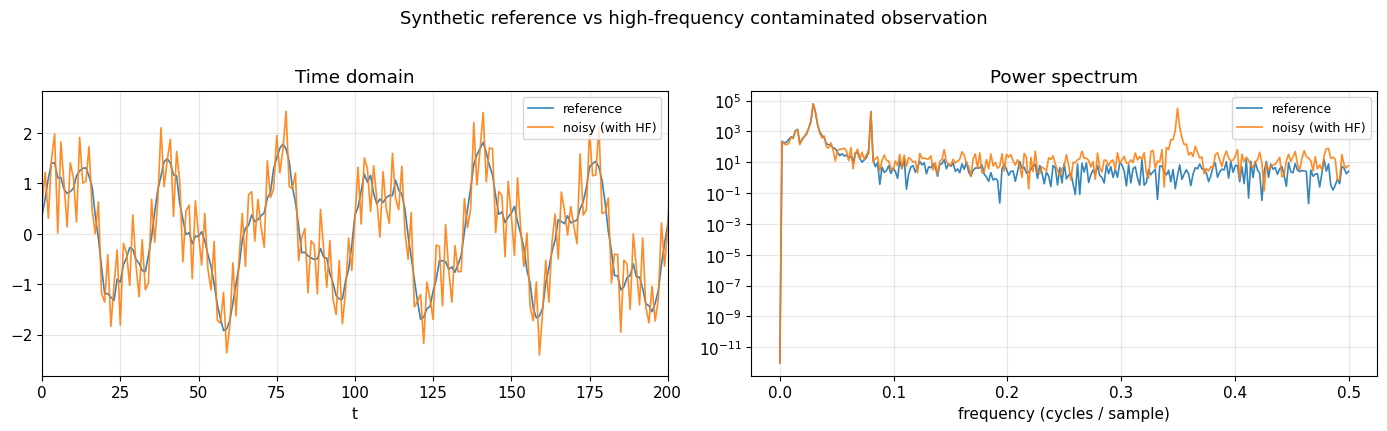

In [3]:
reference = make_periodic_target(SEQ_LEN, seed=0)
noisy = make_spiky_observation(reference, hf_amp=0.75, f_hf=0.35, seed=1)

plot_time_and_spectrum(
    {"reference": reference, "noisy (with HF)": noisy},
    title="Synthetic reference vs high-frequency contaminated observation",
    xlim_time=(0, 200),
)

## 2. Adaptive Cutoff from Cumulative Spectral Energy

`fit(reference)` finds the smallest normalized frequency whose cumulative power reaches
`energy_ratio`, and stores it as `cutoff_`.


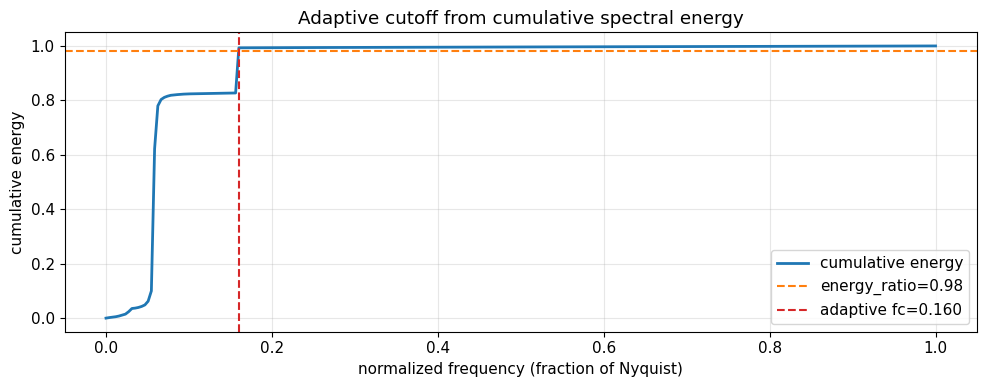

adaptive cutoff_ = 0.1602 (fraction of Nyquist)


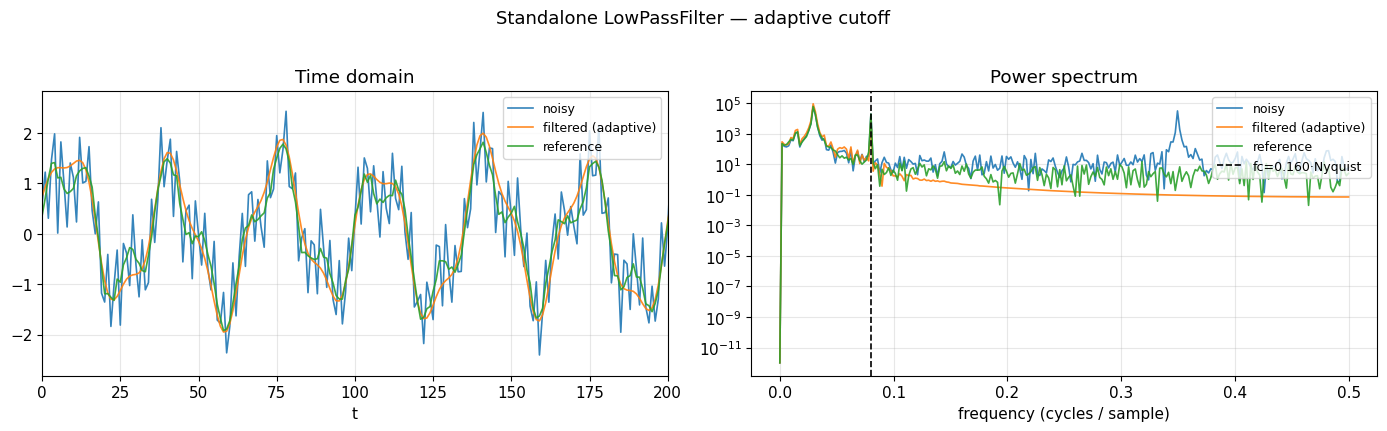

[adaptive] HF power: 2.984e+02 -> 9.713e-02 (ratio=0.000), corr(raw,filt)=0.8457


In [4]:
lpf_adaptive = plot_cumulative_energy(reference, energy_ratio=0.98)
print(f"adaptive cutoff_ = {lpf_adaptive.cutoff_:.4f} (fraction of Nyquist)")

filtered_adaptive = lpf_adaptive.transform(noisy)
plot_time_and_spectrum(
    {
        "noisy": noisy,
        "filtered (adaptive)": filtered_adaptive,
        "reference": reference,
    },
    title="Standalone LowPassFilter - adaptive cutoff",
    cutoff=lpf_adaptive.cutoff_,
    xlim_time=(0, 200),
)
summarize_pair("adaptive", noisy, filtered_adaptive)

## 3. Manual `cutoff` Fully Overrides Adaptation

Lower cutoff => stronger smoothing; higher cutoff => more mid/high-frequency detail retained.


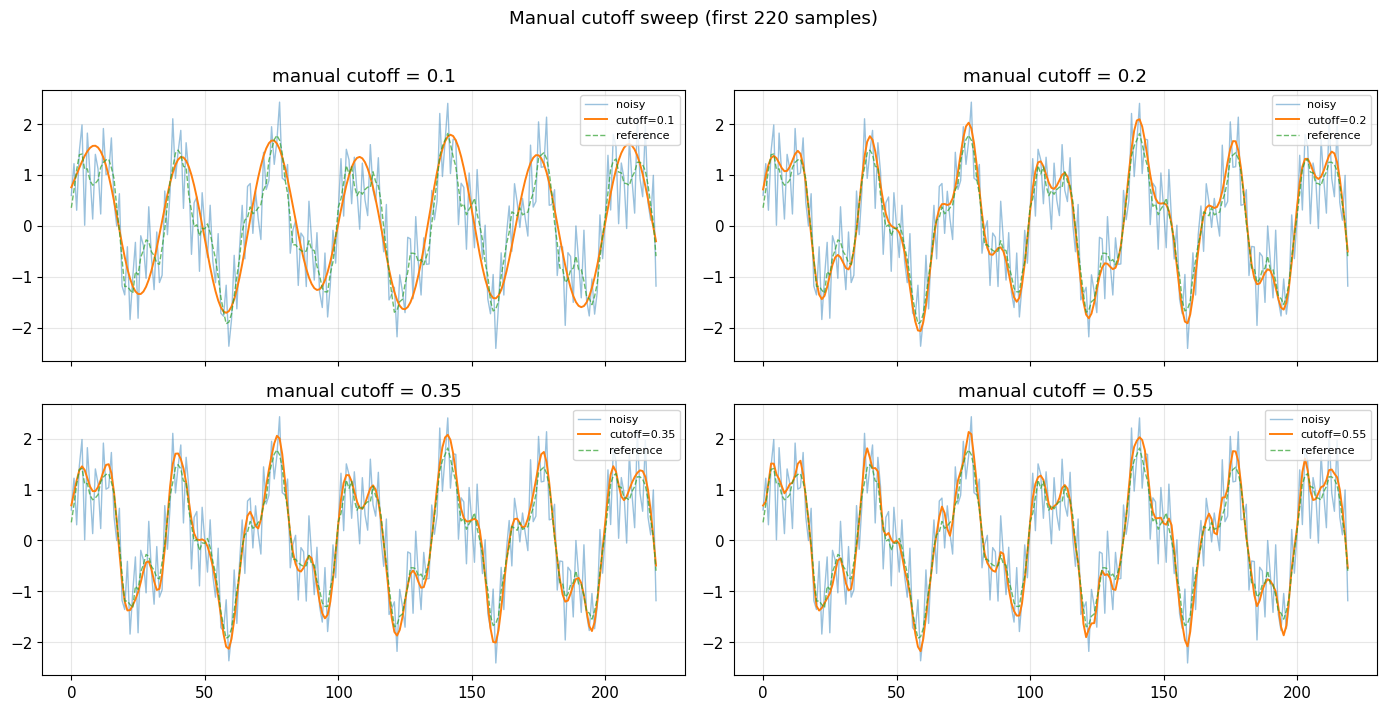

manual override: cutoff_=0.2000 (ignores energy_ratio=0.5)


In [5]:
cutoffs = [0.10, 0.20, 0.35, 0.55]
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)

for ax, cutoff in zip(axes.ravel(), cutoffs):
    y = LowPassFilter(cutoff=cutoff).fit_transform(reference, noisy)
    ax.plot(noisy[:220], alpha=0.45, label="noisy", lw=1)
    ax.plot(y[:220], label=f"cutoff={cutoff}", lw=1.4)
    ax.plot(reference[:220], "--", alpha=0.7, label="reference", lw=1)
    ax.set_title(f"manual cutoff = {cutoff}")
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Manual cutoff sweep (first 220 samples)", y=1.01)
fig.tight_layout()
plt.show()

# confirm override
lpf_manual = LowPassFilter(cutoff=0.2, energy_ratio=0.5).fit(reference)
print(f"manual override: cutoff_={lpf_manual.cutoff_:.4f} (ignores energy_ratio=0.5)")

## 4. `energy_ratio` Sensitivity

Larger `energy_ratio` => higher cutoff => milder smoothing; smaller values suppress HF more.


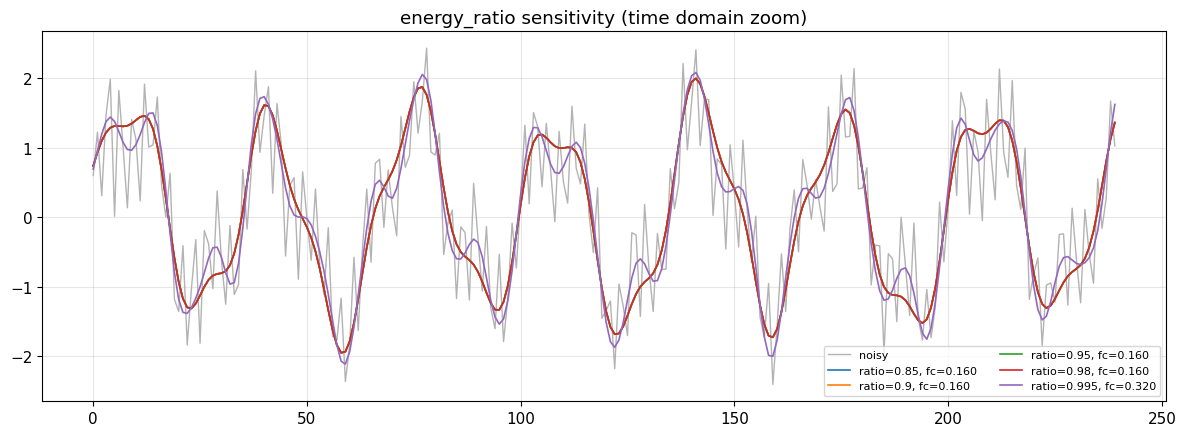

energy_ratio |  cutoff_ |     HF power
----------------------------------------
       0.850 |   0.1602 |    9.713e-02
       0.900 |   0.1602 |    9.713e-02
       0.950 |   0.1602 |    9.713e-02
       0.980 |   0.1602 |    9.713e-02
       0.995 |   0.3203 |    9.987e-02


In [6]:
ratios = [0.85, 0.90, 0.95, 0.98, 0.995]
rows = []
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(noisy[:240], color="0.7", lw=1, label="noisy")

for r in ratios:
    lpf = LowPassFilter(energy_ratio=r).fit(reference)
    y = lpf.transform(noisy)
    ax.plot(y[:240], lw=1.2, label=f"ratio={r}, fc={lpf.cutoff_:.3f}")
    rows.append((r, lpf.cutoff_, high_freq_power(y)))

ax.set_title("energy_ratio sensitivity (time domain zoom)")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

print(f"{'energy_ratio':>12} | {'cutoff_':>8} | {'HF power':>12}")
print("-" * 40)
for r, fc, hf in rows:
    print(f"{r:12.3f} | {fc:8.4f} | {hf:12.3e}")

## 5. Zero-Phase Property and Convenience Helper `apply_lowpass`

Bidirectional `filtfilt` keeps in-band sine peaks aligned; `apply_lowpass` is a one-shot wrapper.


mid-region correlation (zero-phase check): 1.000000


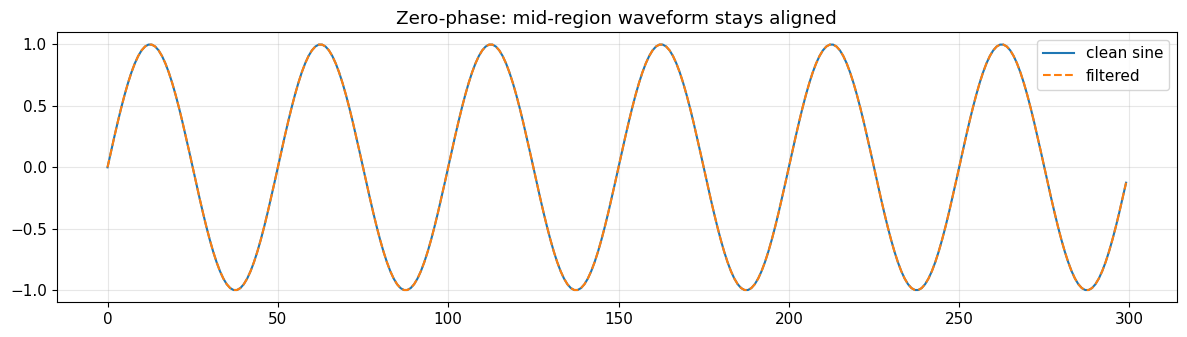

[apply_lowpass] HF power: 2.984e+02 -> 4.957e-02 (ratio=0.000), corr(raw,filt)=0.8644


In [7]:
t = np.arange(512, dtype=np.float64)
clean_sine = np.sin(2 * np.pi * 0.02 * t)
filt_sine = LowPassFilter(cutoff=0.2, revin=False).fit_transform(clean_sine, clean_sine)

mid = slice(100, 400)
corr = float(np.corrcoef(clean_sine[mid], filt_sine[mid])[0, 1])
print(f"mid-region correlation (zero-phase check): {corr:.6f}")

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(clean_sine[mid], label="clean sine", lw=1.5)
ax.plot(filt_sine[mid], "--", label="filtered", lw=1.5)
ax.set_title("Zero-phase: mid-region waveform stays aligned")
ax.legend()
fig.tight_layout()
plt.show()

one_shot = apply_lowpass(noisy, reference, cutoff=0.25)
summarize_pair("apply_lowpass", noisy, one_shot)

## 6. Simulator Integration: Unified Comparison Framework

For the same target series we `fit` then `transform` under three settings:

- `lowpass=False` (default)
- `lowpass=True` (adaptive)
- `lowpass=True, lowpass_kwargs={"cutoff": ...}` (manual)


In [8]:
def compare_simulator(
    name: str,
    make_sim,
    x: np.ndarray,
    num_samples: int = 4,
    manual_cutoff: float = 0.30,
    sample_idx: int = 0,
    fit_kwargs: dict | None = None,
):
    fit_kwargs = {} if fit_kwargs is None else fit_kwargs
    configs = {
        "no lowpass": dict(lowpass=False),
        "adaptive": dict(lowpass=True, lowpass_kwargs={"energy_ratio": 0.98}),
        f"manual fc={manual_cutoff}": dict(
            lowpass=True, lowpass_kwargs={"cutoff": manual_cutoff}
        ),
    }

    results = {}
    cutoffs = {}
    for label, kw in configs.items():
        sim = make_sim(**kw)
        sim.fit(x, **fit_kwargs)
        y = sim.transform(num_samples=num_samples, seq_length=len(x), random_state=0)
        results[label] = y
        lp = getattr(sim, "_lowpass_filter", None)
        cutoffs[label] = None if lp is None else lp.cutoff_

    # time + spectrum for one sample
    series_dict = {"target": x}
    for label, y in results.items():
        series_dict[label] = y[sample_idx]

    fc_show = cutoffs.get("adaptive")
    plot_time_and_spectrum(
        series_dict,
        title=f"{name}: target vs generated (sample #{sample_idx})",
        cutoff=fc_show,
        xlim_time=(0, 220),
    )

    # overlay multiple generated paths (no-lp vs adaptive)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    for i in range(min(num_samples, 4)):
        axes[0].plot(results["no lowpass"][i], alpha=0.7, lw=1)
        axes[1].plot(results["adaptive"][i], alpha=0.7, lw=1)
    axes[0].plot(x, "k--", lw=1.2, alpha=0.8, label="target")
    axes[1].plot(x, "k--", lw=1.2, alpha=0.8, label="target")
    axes[0].set_title(f"{name} — without lowpass")
    axes[1].set_title(
        f"{name} — adaptive lowpass (fc={cutoffs['adaptive']:.3f})"
        if cutoffs["adaptive"] is not None
        else f"{name} — adaptive lowpass"
    )
    for ax in axes:
        ax.set_xlim(0, 220)
        ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

    print(f"=== {name} ===")
    for label, y in results.items():
        fc = cutoffs[label]
        fc_str = "n/a" if fc is None else f"{fc:.4f}"
        gen = y[sample_idx]
        print(
            f"  {label:20s} cutoff_={fc_str} | "
            f"HF(target)={high_freq_power(x):.3e}, "
            f"HF(gen)={high_freq_power(gen):.3e}, "
            f"corr(target,gen)={np.corrcoef(x, gen)[0, 1]:.4f}"
        )
    return results, cutoffs


target = make_periodic_target(SEQ_LEN, seed=42)
print("target ready, len =", len(target))

target ready, len = 512


## 7. WienerFilterSimulator (Most Glitchy; Largest Low-Pass Benefit)


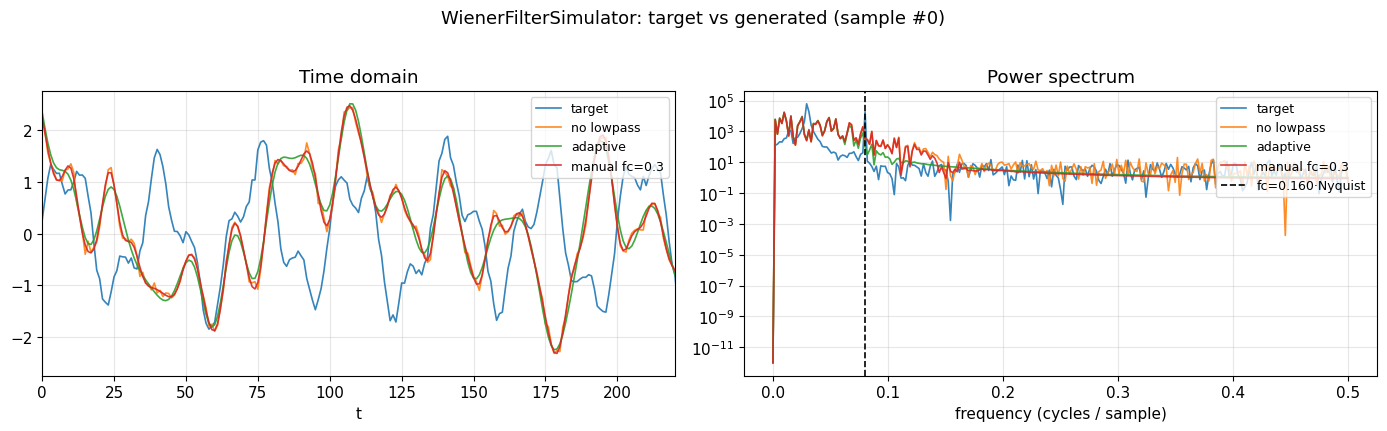

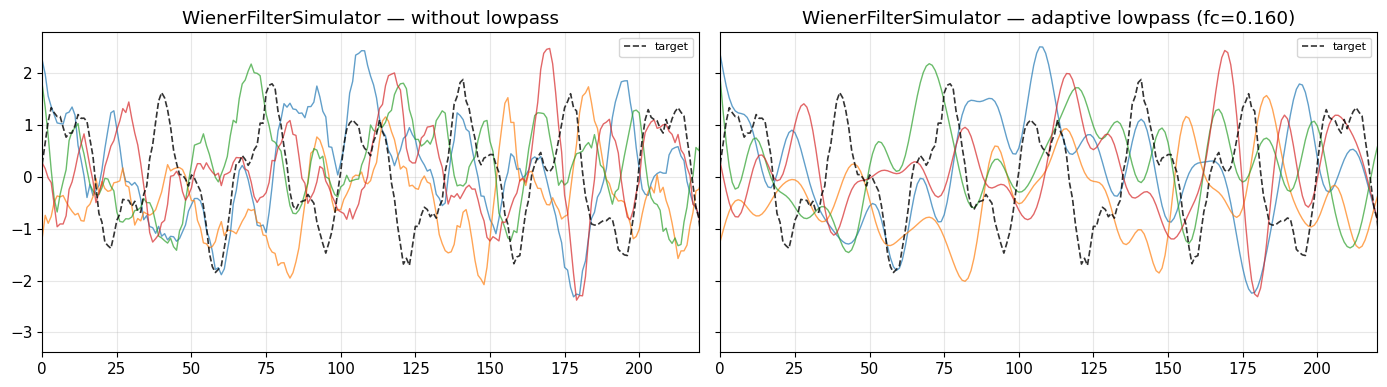

=== WienerFilterSimulator ===
  no lowpass           cutoff_=n/a | HF(target)=3.377e+00, HF(gen)=4.331e+00, corr(target,gen)=0.0353
  adaptive             cutoff_=0.1602 | HF(target)=3.377e+00, HF(gen)=1.302e+00, corr(target,gen)=0.0500
  manual fc=0.3        cutoff_=0.3000 | HF(target)=3.377e+00, HF(gen)=1.123e+00, corr(target,gen)=0.0362


In [9]:
wiener_results, wiener_cutoffs = compare_simulator(
    "WienerFilterSimulator",
    lambda **kw: WienerFilterSimulator(filter_order=8, random_state=0, **kw),
    target,
    num_samples=4,
    manual_cutoff=0.30,
)

### 7.1 Wiener: Zoom In on Glitch Removal


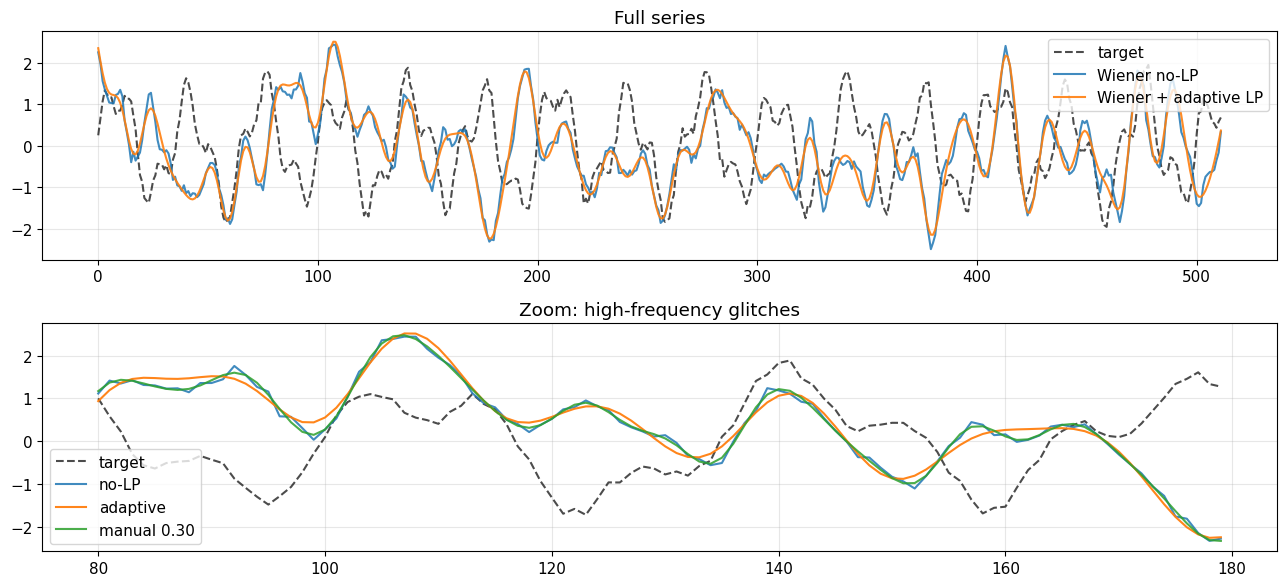

Wiener adaptive cutoff_ = 0.1602
HF power no-LP / adaptive / manual = 4.331e+00 / 1.302e+00 / 1.123e+00


In [10]:
raw = wiener_results["no lowpass"][0]
smooth = wiener_results["adaptive"][0]
manual = wiener_results["manual fc=0.3"][0]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=False)
zoom = slice(80, 180)
axes[0].plot(target, "k--", alpha=0.7, label="target")
axes[0].plot(raw, alpha=0.85, label="Wiener no-LP")
axes[0].plot(smooth, alpha=0.9, label="Wiener + adaptive LP")
axes[0].set_title("Full series")
axes[0].legend()

axes[1].plot(np.arange(80, 180), target[zoom], "k--", alpha=0.7, label="target")
axes[1].plot(np.arange(80, 180), raw[zoom], alpha=0.85, label="no-LP")
axes[1].plot(np.arange(80, 180), smooth[zoom], alpha=0.95, label="adaptive")
axes[1].plot(np.arange(80, 180), manual[zoom], alpha=0.85, label="manual 0.30")
axes[1].set_title("Zoom: high-frequency glitches")
axes[1].legend()
fig.tight_layout()
plt.show()

print(
    f"Wiener adaptive cutoff_ = {wiener_cutoffs['adaptive']:.4f}\n"
    f"HF power no-LP / adaptive / manual = "
    f"{high_freq_power(raw):.3e} / {high_freq_power(smooth):.3e} / {high_freq_power(manual):.3e}"
)

## 8. KalmanFilterSimulator


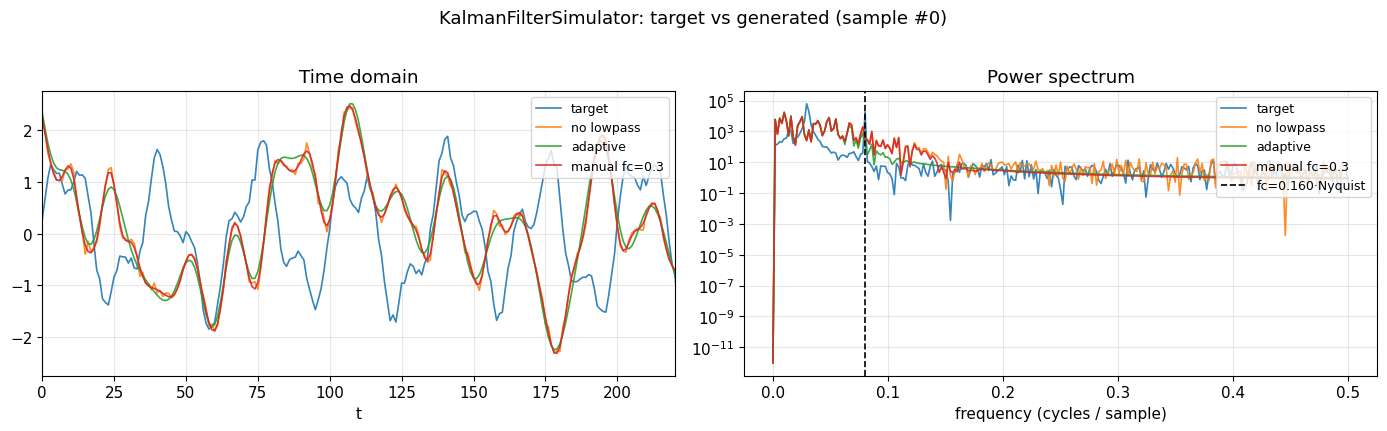

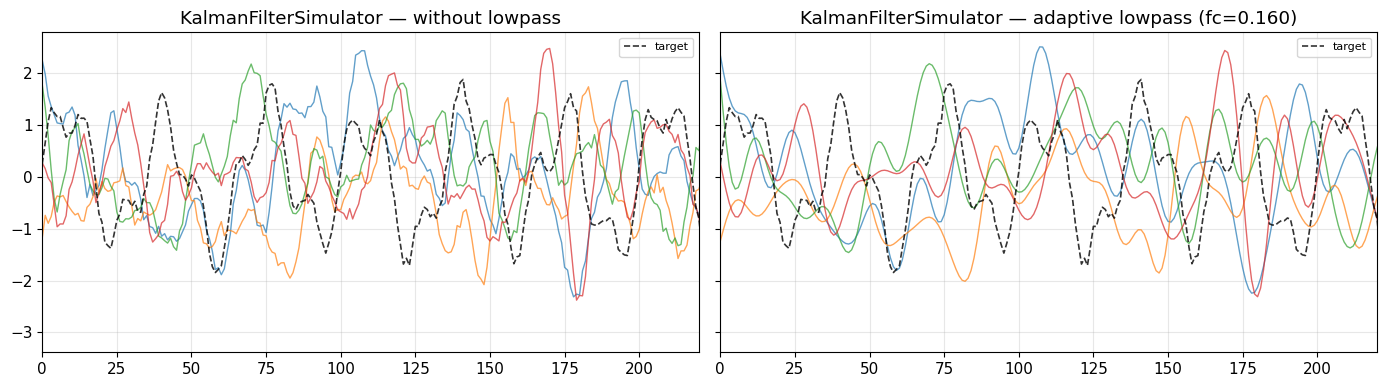

=== KalmanFilterSimulator ===
  no lowpass           cutoff_=n/a | HF(target)=3.377e+00, HF(gen)=4.331e+00, corr(target,gen)=0.0353
  adaptive             cutoff_=0.1602 | HF(target)=3.377e+00, HF(gen)=1.302e+00, corr(target,gen)=0.0500
  manual fc=0.3        cutoff_=0.3000 | HF(target)=3.377e+00, HF(gen)=1.123e+00, corr(target,gen)=0.0362


In [11]:
_ = compare_simulator(
    "KalmanFilterSimulator",
    lambda **kw: KalmanFilterSimulator(state_order=8, random_state=0, **kw),
    target,
    num_samples=4,
    manual_cutoff=0.30,
)

## 9. ARIMASimulator

For a faster demo we use smaller `max_p/d/q` and disable the non-white residual alarm.


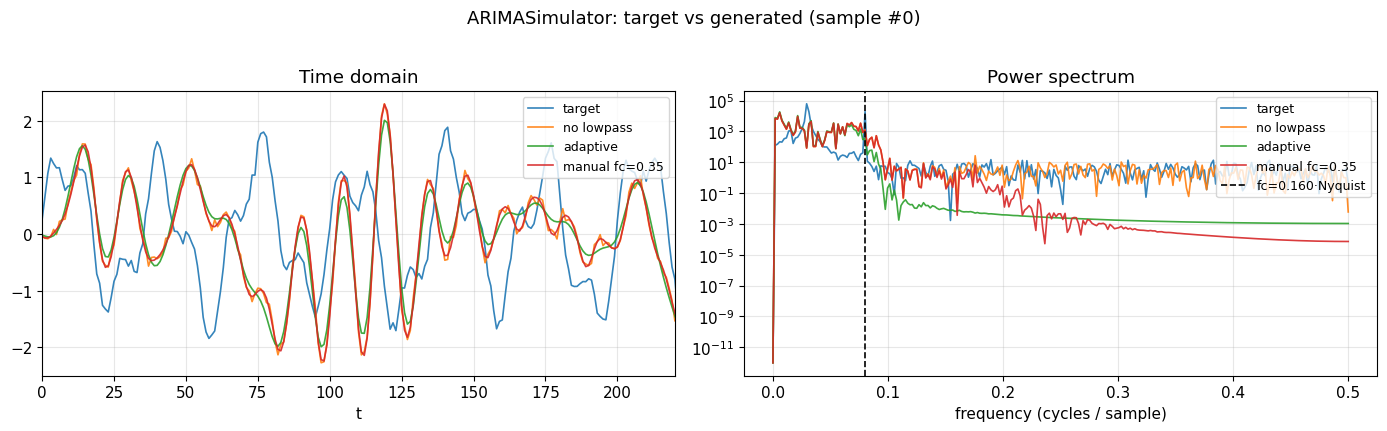

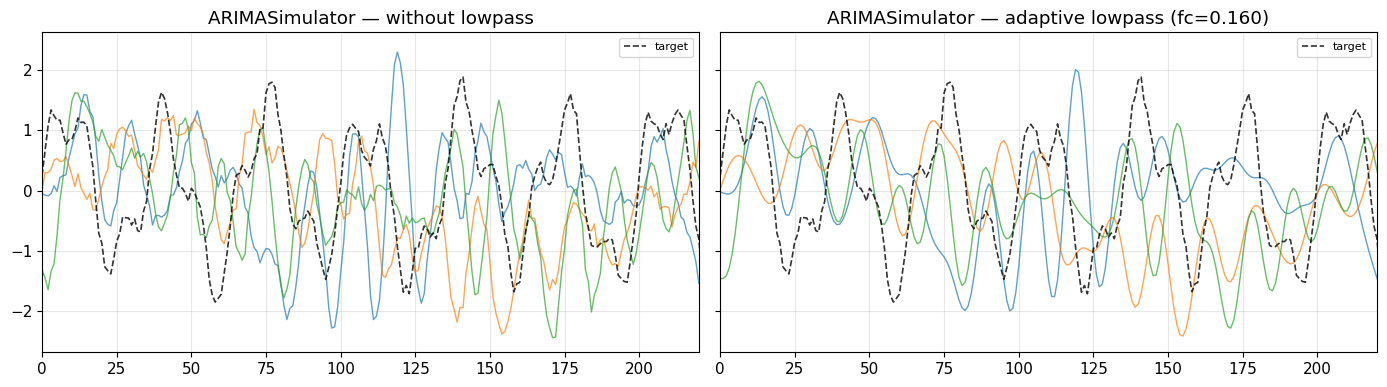

=== ARIMASimulator ===
  no lowpass           cutoff_=n/a | HF(target)=3.377e+00, HF(gen)=2.854e+00, corr(target,gen)=0.0762
  adaptive             cutoff_=0.1602 | HF(target)=3.377e+00, HF(gen)=1.413e-03, corr(target,gen)=0.0686
  manual fc=0.35       cutoff_=0.3500 | HF(target)=3.377e+00, HF(gen)=4.071e-04, corr(target,gen)=0.0768


In [12]:
_ = compare_simulator(
    "ARIMASimulator",
    lambda **kw: ARIMASimulator(
        max_p=3,
        max_d=1,
        max_q=3,
        not_white_alarm=False,
        random_state=0,
        **kw,
    ),
    target,
    num_samples=3,
    manual_cutoff=0.35,
    fit_kwargs={"select_order": True},
)

## 10. MarkovSwitchingSimulator

Use a regime-like piecewise target and check whether low-pass removes switching edges
versus only high-frequency roughness.


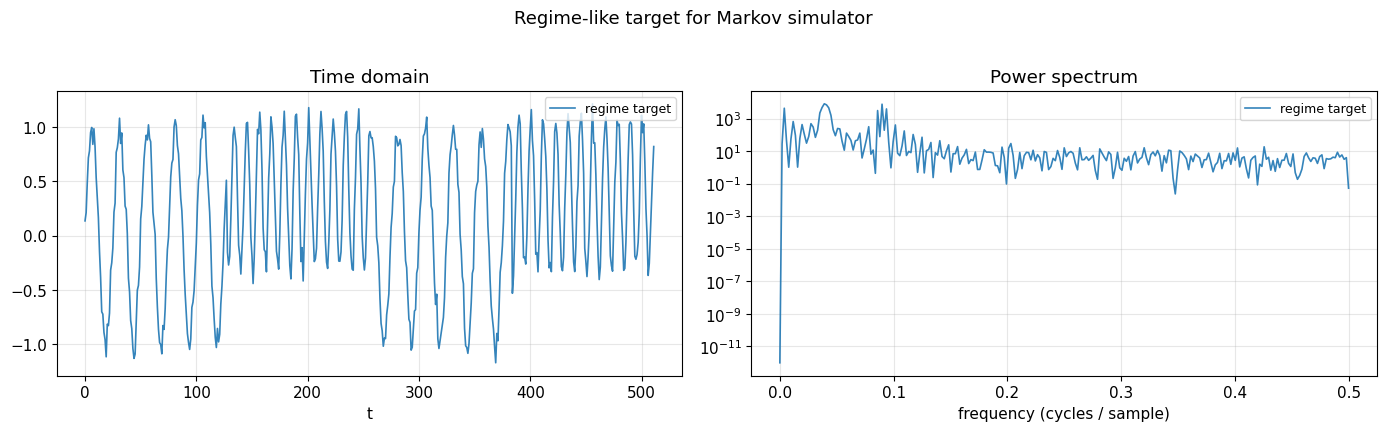

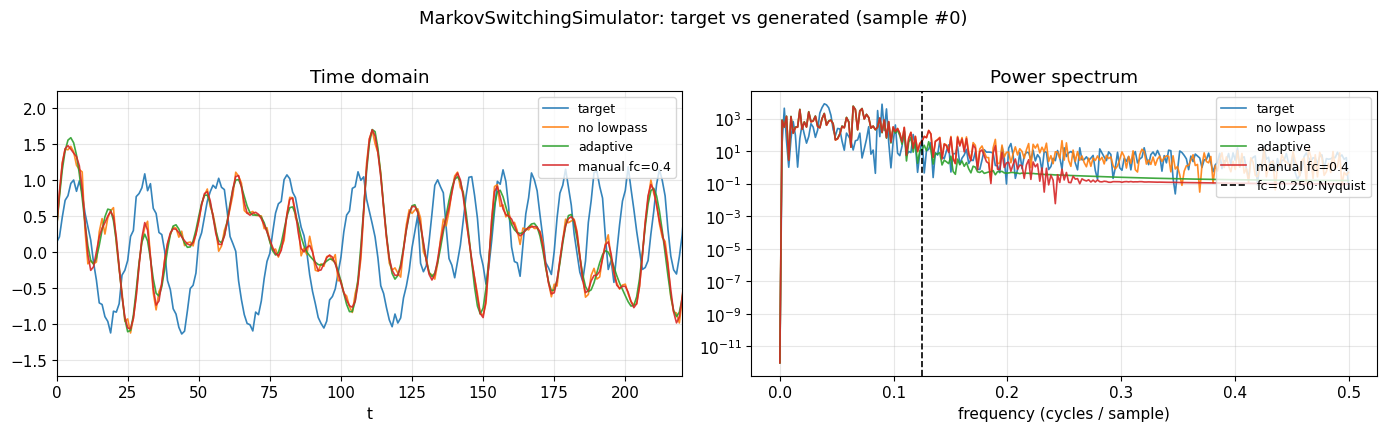

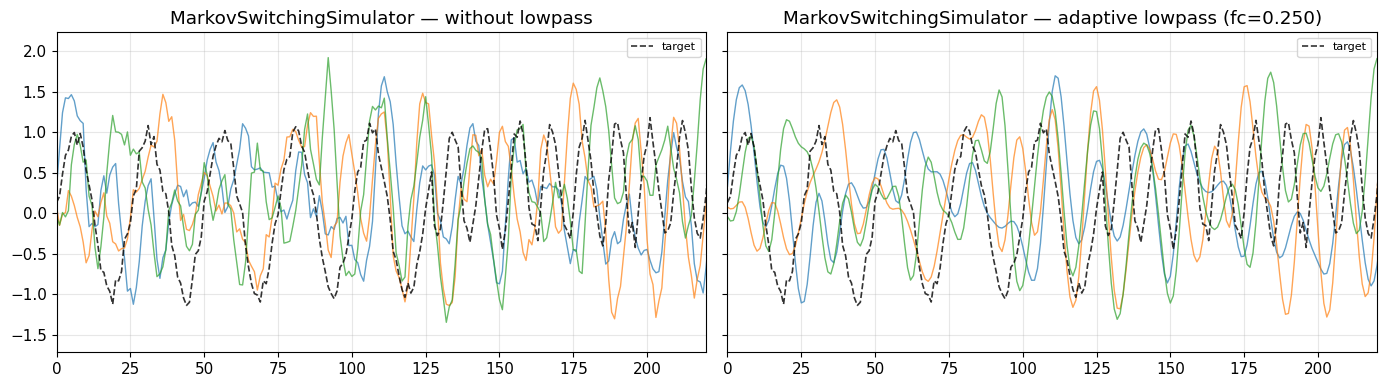

=== MarkovSwitchingSimulator ===
  no lowpass           cutoff_=n/a | HF(target)=4.179e+00, HF(gen)=3.309e+00, corr(target,gen)=0.0676
  adaptive             cutoff_=0.2500 | HF(target)=4.179e+00, HF(gen)=2.027e-01, corr(target,gen)=0.0702
  manual fc=0.4        cutoff_=0.4000 | HF(target)=4.179e+00, HF(gen)=1.203e-01, corr(target,gen)=0.0683


In [13]:
def make_regime_target(n: int = SEQ_LEN, seed: int = 7) -> np.ndarray:
    rng = np.random.RandomState(seed)
    t = np.arange(n, dtype=np.float64)
    x = np.zeros(n)
    # two alternating oscillatory regimes
    for start in range(0, n, 128):
        end = min(start + 128, n)
        if (start // 128) % 2 == 0:
            x[start:end] = 1.0 * np.sin(2 * np.pi * 0.04 * t[start:end])
        else:
            x[start:end] = 0.7 * np.sin(2 * np.pi * 0.09 * t[start:end] + 1.0) + 0.4
    x += 0.08 * rng.randn(n)
    return x


regime_x = make_regime_target()
plot_time_and_spectrum(
    {"regime target": regime_x}, title="Regime-like target for Markov simulator"
)

_ = compare_simulator(
    "MarkovSwitchingSimulator",
    lambda **kw: MarkovSwitchingSimulator(
        max_k_regimes=2,
        max_order=2,
        not_white_alarm=False,
        maxiter=80,
        random_state=0,
        **kw,
    ),
    regime_x,
    num_samples=3,
    manual_cutoff=0.40,
    fit_kwargs={"select_order": True},
)

## 11. GaussianMixtureSimulator


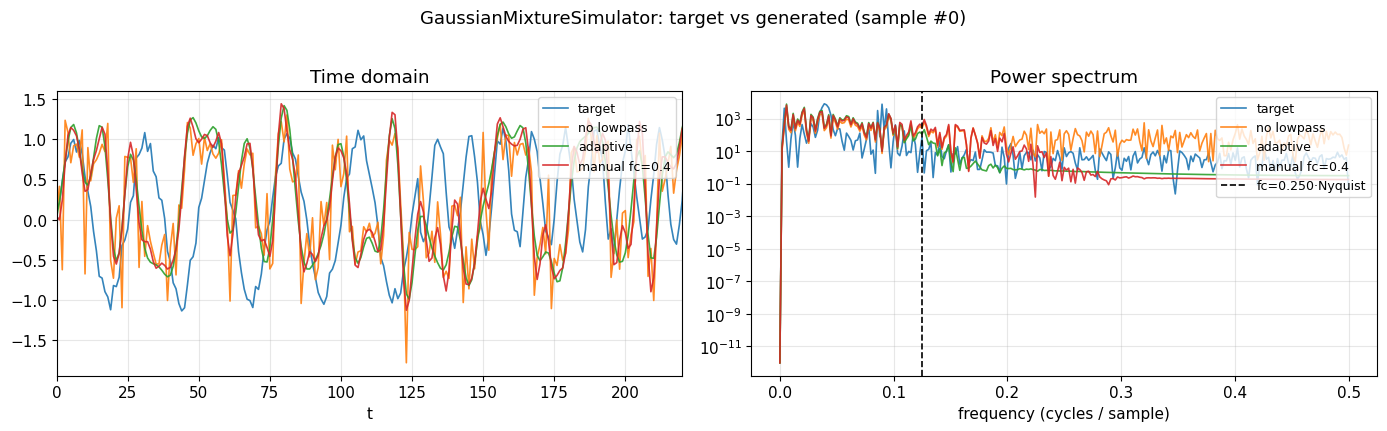

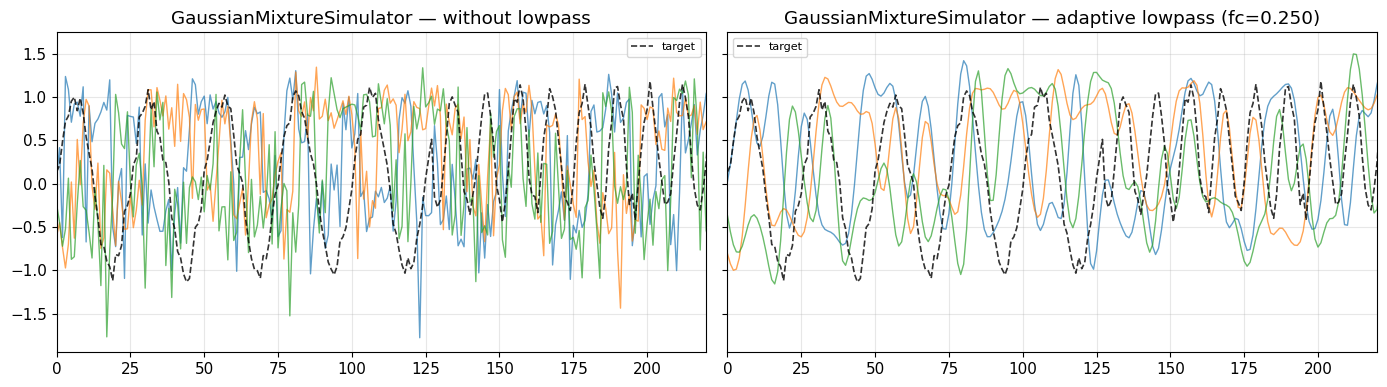

=== GaussianMixtureSimulator ===
  no lowpass           cutoff_=n/a | HF(target)=4.179e+00, HF(gen)=8.777e+01, corr(target,gen)=0.0087
  adaptive             cutoff_=0.2500 | HF(target)=4.179e+00, HF(gen)=3.910e-01, corr(target,gen)=0.0049
  manual fc=0.4        cutoff_=0.4000 | HF(target)=4.179e+00, HF(gen)=2.355e-01, corr(target,gen)=0.0091


In [14]:
_ = compare_simulator(
    "GaussianMixtureSimulator",
    lambda **kw: GaussianMixtureSimulator(
        n_components=2,
        max_n_components=3,
        not_white_alarm=False,
        random_state=0,
        **kw,
    ),
    regime_x,
    num_samples=3,
    manual_cutoff=0.40,
)

## 12. MultivariateSimulator (Per-Channel Sub-Simulator Post-Processing)

Pass `lowpass=True` on the template so each channel estimates its own cutoff during `fit`,
and applies it on the shared-excitation `invoke` path.


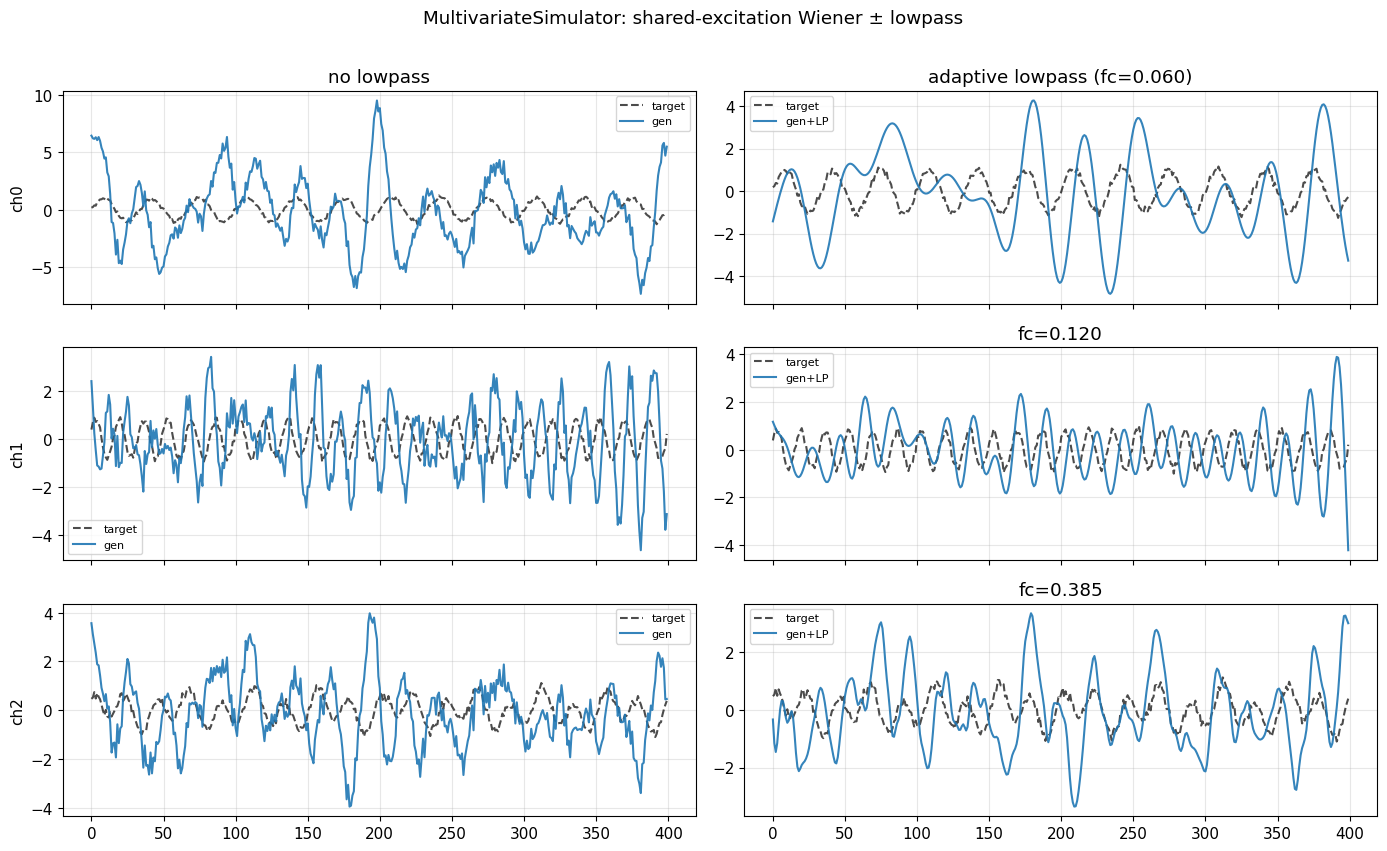

ch0: HF no-LP=1.114e+02, HF+LP=1.116e+00, cutoff_=0.0600
ch1: HF no-LP=8.788e+01, HF+LP=1.252e+01, cutoff_=0.1200
ch2: HF no-LP=5.113e+01, HF+LP=2.440e+00, cutoff_=0.3850


In [17]:
def make_multivariate(n: int = 400, c: int = 3, seed: int = 3) -> np.ndarray:
    rng = np.random.RandomState(seed)
    t = np.arange(n, dtype=np.float64)
    X = np.column_stack(
        [
            np.sin(2 * np.pi * 0.03 * t) + 0.1 * rng.randn(n),
            0.8 * np.sin(2 * np.pi * 0.06 * t + 0.5) + 0.1 * rng.randn(n),
            0.6 * np.sin(2 * np.pi * 0.045 * t + 1.2)
            + 0.35 * np.sin(2 * np.pi * 0.02 * t)
            + 0.1 * rng.randn(n),
        ]
    )
    return X


X_mv = make_multivariate()

mv_off = MultivariateSimulator(
    WienerFilterSimulator(filter_order=6, random_state=0, lowpass=False),
    n_jobs=1,
)
mv_on = MultivariateSimulator(
    WienerFilterSimulator(
        filter_order=24,
        random_state=0,
        lowpass=True,
        lowpass_kwargs={"energy_ratio": 0.97},
    ),
    n_jobs=1,
)

mv_off.fit(X_mv)
mv_on.fit(X_mv)
Y_off = mv_off.transform(num_samples=2, seq_length=X_mv.shape[0], random_state=0)
Y_on = mv_on.transform(num_samples=2, seq_length=X_mv.shape[0], random_state=0)

n_ch = X_mv.shape[1]
fig, axes = plt.subplots(n_ch, 2, figsize=(14, 2.8 * n_ch), sharex=True)
for c in range(n_ch):
    axes[c, 0].plot(X_mv[:, c], "k--", alpha=0.7, label="target")
    axes[c, 0].plot(Y_off[0, :, c], alpha=0.9, label="gen")
    axes[c, 0].set_ylabel(f"ch{c}")
    axes[c, 0].set_title("no lowpass" if c == 0 else "")
    axes[c, 0].legend(fontsize=8)

    axes[c, 1].plot(X_mv[:, c], "k--", alpha=0.7, label="target")
    axes[c, 1].plot(Y_on[0, :, c], alpha=0.9, label="gen+LP")
    fc = mv_on.simulators[c]._lowpass_filter.cutoff_
    axes[c, 1].set_title(
        f"adaptive lowpass (fc={fc:.3f})" if c == 0 else f"fc={fc:.3f}"
    )
    axes[c, 1].legend(fontsize=8)

fig.suptitle("MultivariateSimulator: shared-excitation Wiener +/- lowpass", y=1.01)
fig.tight_layout()
plt.show()

for c in range(n_ch):
    print(
        f"ch{c}: HF no-LP={high_freq_power(Y_off[0,:,c]):.3e}, "
        f"HF+LP={high_freq_power(Y_on[0,:,c]):.3e}, "
        f"cutoff_={mv_on.simulators[c]._lowpass_filter.cutoff_:.4f}"
    )

## 13. Cross-Simulator Summary: High-Frequency Power Reduction

Quick sweep on the same `target` (Markov / GMM use the regime target).


Simulator  |     HF no-LP |        HF+LP | reduction |      fc
--------------------------------------------------------------
Wiener     |    3.218e+00 |    2.422e-02 |     99.2% |  0.1602
Kalman     |    3.218e+00 |    2.422e-02 |     99.2% |  0.1602
ARIMA      |    3.384e+00 |    2.824e-02 |     99.2% |  0.1602
Markov     |    3.308e+00 |    3.514e-02 |     98.9% |  0.2500
GMM        |    7.951e+01 |    6.929e-01 |     99.1% |  0.2500


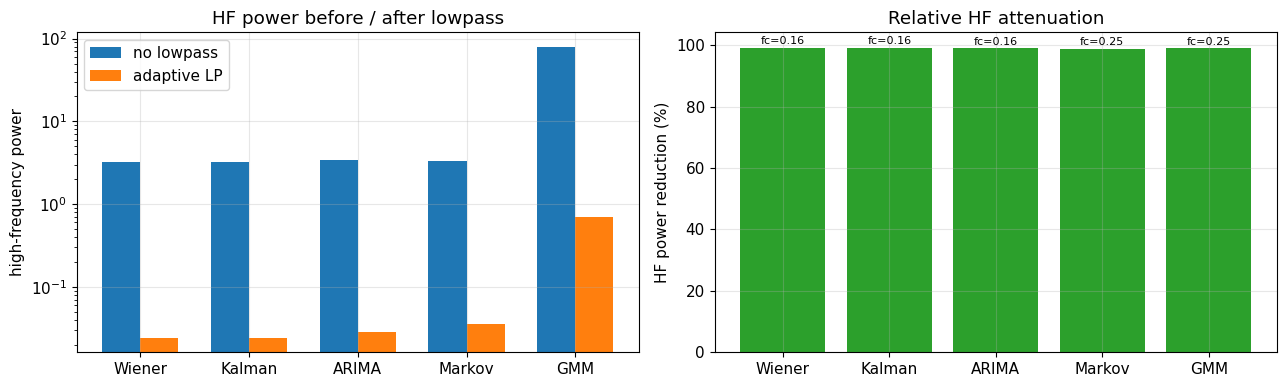

In [16]:
def hf_reduction_for(make_sim, x, fit_kwargs=None):
    fit_kwargs = {} if fit_kwargs is None else fit_kwargs
    sim0 = make_sim(lowpass=False)
    sim1 = make_sim(lowpass=True, lowpass_kwargs={"energy_ratio": 0.98})
    sim0.fit(x, **fit_kwargs)
    sim1.fit(x, **fit_kwargs)
    y0 = sim0.transform(num_samples=1, seq_length=len(x), random_state=1)[0]
    y1 = sim1.transform(num_samples=1, seq_length=len(x), random_state=1)[0]
    h0, h1 = high_freq_power(y0), high_freq_power(y1)
    fc = sim1._lowpass_filter.cutoff_
    return h0, h1, (1 - h1 / h0) if h0 > 0 else np.nan, fc


bench = [
    (
        "Wiener",
        lambda **kw: WienerFilterSimulator(filter_order=8, random_state=0, **kw),
        target,
        {},
    ),
    (
        "Kalman",
        lambda **kw: KalmanFilterSimulator(state_order=8, random_state=0, **kw),
        target,
        {},
    ),
    (
        "ARIMA",
        lambda **kw: ARIMASimulator(
            max_p=3, max_d=1, max_q=3, not_white_alarm=False, random_state=0, **kw
        ),
        target,
        {"select_order": True},
    ),
    (
        "Markov",
        lambda **kw: MarkovSwitchingSimulator(
            max_k_regimes=2,
            max_order=2,
            not_white_alarm=False,
            maxiter=60,
            random_state=0,
            **kw,
        ),
        regime_x,
        {"select_order": True},
    ),
    (
        "GMM",
        lambda **kw: GaussianMixtureSimulator(
            n_components=2, not_white_alarm=False, random_state=0, **kw
        ),
        regime_x,
        {},
    ),
]

names, reductions, cutoffs_b, hf_pairs = [], [], [], []
print(
    f"{'Simulator':10s} | {'HF no-LP':>12s} | {'HF+LP':>12s} | {'reduction':>9s} | {'fc':>7s}"
)
print("-" * 62)
for name, factory, x, fkw in bench:
    h0, h1, red, fc = hf_reduction_for(factory, x, fkw)
    names.append(name)
    reductions.append(100 * red)
    cutoffs_b.append(fc)
    hf_pairs.append((h0, h1))
    print(f"{name:10s} | {h0:12.3e} | {h1:12.3e} | {100*red:8.1f}% | {fc:7.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x_pos = np.arange(len(names))
w = 0.35
h0s = [p[0] for p in hf_pairs]
h1s = [p[1] for p in hf_pairs]
axes[0].bar(x_pos - w / 2, h0s, width=w, label="no lowpass")
axes[0].bar(x_pos + w / 2, h1s, width=w, label="adaptive LP")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(names)
axes[0].set_yscale("log")
axes[0].set_ylabel("high-frequency power")
axes[0].set_title("HF power before / after lowpass")
axes[0].legend()

axes[1].bar(x_pos, reductions, color="C2")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(names)
axes[1].set_ylabel("HF power reduction (%)")
axes[1].set_title("Relative HF attenuation")
for i, fc in enumerate(cutoffs_b):
    axes[1].text(i, reductions[i] + 1, f"fc={fc:.2f}", ha="center", fontsize=8)
fig.tight_layout()
plt.show()

## 14. Practical Tips

| Scenario | Suggestion |
| --- | --- |
| Wiener outputs look spiky | `lowpass=True` (adaptive `energy_ratio=0.98`) |
| Keep more mid/high-frequency cycles | Raise `energy_ratio` or set a larger manual `cutoff` (e.g. `0.35~0.55`) |
| Need stronger smoothing | Smaller manual `cutoff` (e.g. `0.10~0.20`) |
| Multivariate series | Enable `lowpass` on each sub-simulator template (per-channel adaptation) |
| Default behavior | `lowpass=False` matches the previous API |

```python
from s2generator.simulator import WienerFilterSimulator

sim = WienerFilterSimulator(lowpass=True)  # adaptive
sim.fit(x)
y = sim.transform(num_samples=8, seq_length=len(x))

sim = WienerFilterSimulator(lowpass=True, lowpass_kwargs={"cutoff": 0.35})  # manual
```
